## EDA and dataset Sanity

### Random Trajectory dataset

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def load_episode(path):
    return np.load(path, allow_pickle=True)

def load_all_episodes(folder):
    episode_files = sorted(glob.glob(os.path.join(folder, "*.npz")))
    return episode_files

num episodes: 200
['images', 'robot_states', 'actions', 'rewards', 'next_images', 'next_robot_states', 'dones']
images: (200, 480, 480, 3)
robot_states: (200, 4)
actions: (200, 4)
rewards: (200,)
first robot state: [0.0045842  0.60138811 0.19514345 1.        ]
first action: [-0.11659492  0.07134298 -0.8822927  -0.78968745]
first reward: 1.4532866894437535


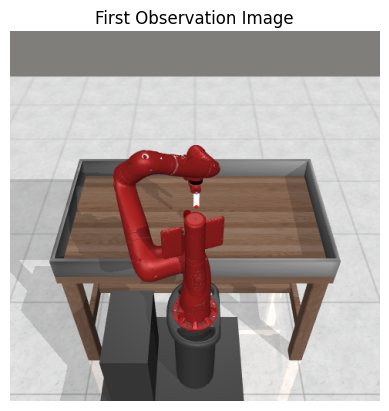

In [2]:
random_dir = "../datasets/reach_random/trajectories"

episode_files = load_all_episodes(random_dir)

print("num episodes:", len(episode_files))

data = load_episode(episode_files[0])

print(data.files)

print("images:", data["images"].shape)
print("robot_states:", data["robot_states"].shape)
print("actions:", data["actions"].shape)
print("rewards:", data["rewards"].shape)

print("first robot state:", data["robot_states"][0])
print("first action:", data["actions"][0])
print("first reward:", data["rewards"][0])

plt.imshow(data["images"][0])
plt.title("First Observation Image")
plt.axis("off")
plt.show()

In [3]:
episode_returns = []

for ep_path in episode_files:
    ep = load_episode(ep_path)
    episode_returns.append(np.sum(ep["rewards"]))

print("mean return:", np.mean(episode_returns))
print("min return:", np.min(episode_returns))
print("max return:", np.max(episode_returns))

mean return: 312.4102306258387
min return: 141.66803657011522
max return: 972.6709239523626


In [4]:
lengths = []

for ep_path in episode_files:
    ep = load_episode(ep_path)
    lengths.append(len(ep["rewards"]))

print("avg length:", np.mean(lengths))
print("std length:", np.std(lengths))
print("min/max:", np.min(lengths), np.max(lengths))

avg length: 200.0
std length: 0.0
min/max: 200 200


In [5]:
all_states = []

for ep_path in episode_files:
    ep = load_episode(ep_path)
    all_states.append(ep["robot_states"])

all_states = np.concatenate(all_states, axis=0)

print("robot state variance:", np.var(all_states, axis=0))

robot state variance: [0.00337387 0.00276893 0.00305528 0.04081472]


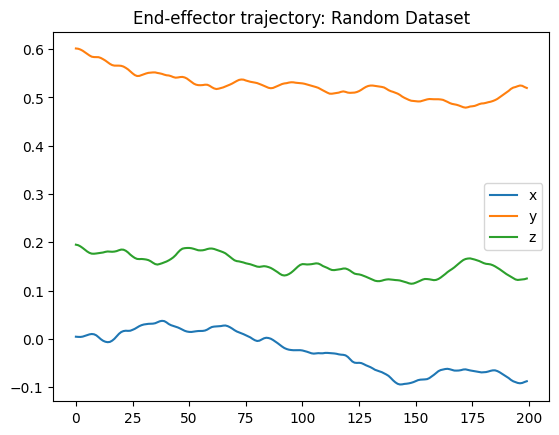

In [6]:
states = data["robot_states"]

plt.plot(states[:, 0], label="x")
plt.plot(states[:, 1], label="y")
plt.plot(states[:, 2], label="z")

plt.legend()
plt.title("End-effector trajectory: Random Dataset")
plt.savefig("../docs/random_traj.png")
plt.show()

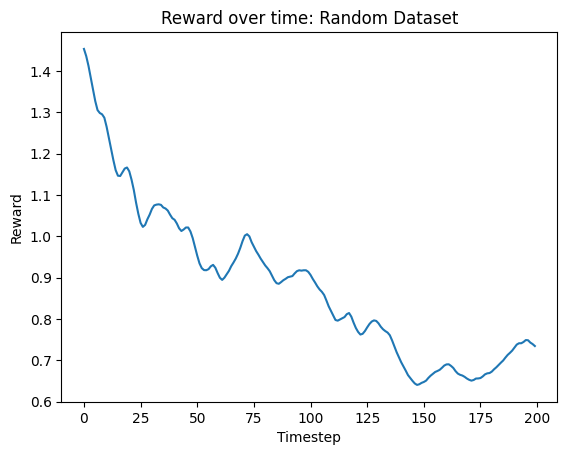

In [7]:
plt.plot(data["rewards"])

plt.title("Reward over time: Random Dataset")
plt.xlabel("Timestep")
plt.ylabel("Reward")
plt.savefig("../docs/reward_time_random.png")
plt.show()

### Expert Trajectory dataset

num episodes: 200
['images', 'robot_states', 'actions', 'rewards', 'next_images', 'dones']
images: (200, 480, 480, 3)
robot_states: (200, 4)
actions: (200, 4)
rewards: (200,)
first robot state: [0.0045842  0.60138811 0.19514345 1.        ]
first action: [ 0.41095033  1.3066747  -0.19007322  0.        ]
first reward: 1.483829604471403


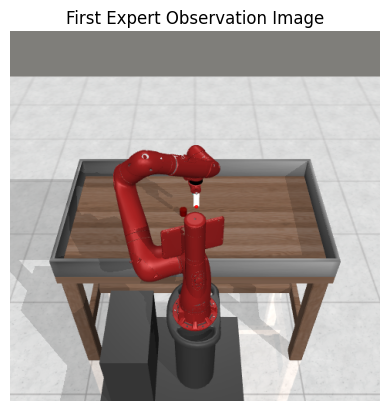

In [8]:
expert_dir = "../datasets/reach_expert/trajectories"

expert_episode_files = load_all_episodes(expert_dir)

print("num episodes:", len(expert_episode_files))

expert_data = load_episode(expert_episode_files[0])

print(expert_data.files)

print("images:", expert_data["images"].shape)
print("robot_states:", expert_data["robot_states"].shape)
print("actions:", expert_data["actions"].shape)
print("rewards:", expert_data["rewards"].shape)

print("first robot state:", expert_data["robot_states"][0])
print("first action:", expert_data["actions"][0])
print("first reward:", expert_data["rewards"][0])

plt.imshow(expert_data["images"][0])
plt.title("First Expert Observation Image")
plt.axis("off")
plt.show()

In [9]:
expert_returns = []

for ep_path in expert_episode_files:
    ep = load_episode(ep_path)
    expert_returns.append(np.sum(ep["rewards"]))

print("mean return:", np.mean(expert_returns))
print("min return:", np.min(expert_returns))
print("max return:", np.max(expert_returns))

mean return: 1838.6363666528184
min return: 1791.014560866764
max return: 1886.250058948317


In [10]:
expert_lengths = []

for ep_path in expert_episode_files:
    ep = load_episode(ep_path)
    expert_lengths.append(len(ep["rewards"]))

print("avg length:", np.mean(expert_lengths))
print("std length:", np.std(expert_lengths))
print("min/max:", np.min(expert_lengths), np.max(expert_lengths))

avg length: 200.0
std length: 0.0
min/max: 200 200


In [11]:
all_states = np.concatenate(
    [load_episode(ep_path)["robot_states"] for ep_path in expert_episode_files],
    axis=0
)

print("state variance:", np.var(all_states, axis=0)[:5])

state variance: [2.92188358e-03 4.49992512e-03 4.12435041e-03 5.63466066e-07]


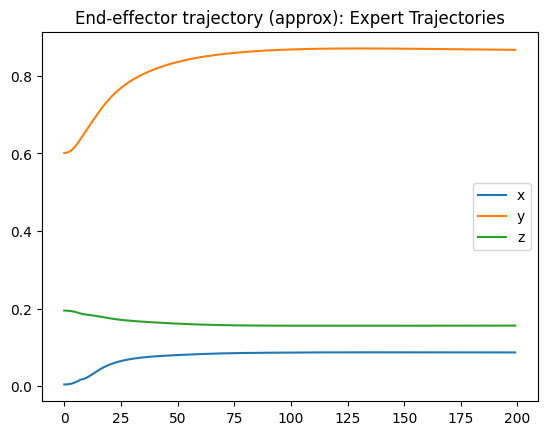

In [12]:
episode = load_episode(expert_episode_files[0])
obs = episode["robot_states"]

plt.plot(obs[:, 0], label="x")
plt.plot(obs[:, 1], label="y")
plt.plot(obs[:, 2], label="z")

plt.legend()
plt.title("End-effector trajectory (approx): Expert Trajectories")

plt.savefig("../docs/end_effector_expert.png")
plt.show()

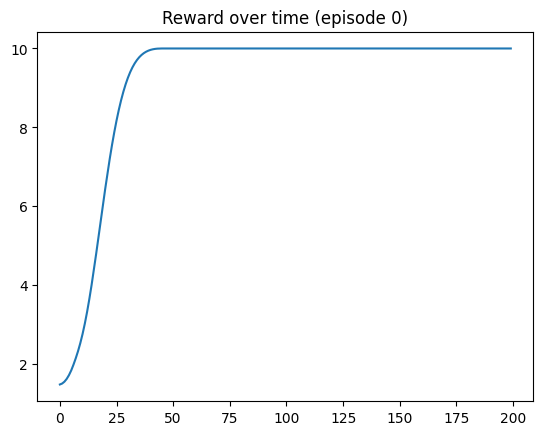

In [13]:
plt.plot(episode["rewards"])
plt.title("Reward over time (episode 0)")
plt.savefig("../docs/rewards_time_expert.png")
plt.show()